## block count latency device

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_block_count_latency_device = pd.read_csv("block_count_latency_device.csv")
df_read_bytes = pd.read_csv("read_bytes.csv")
df_write_bytes = pd.read_csv("write_bytes.csv")


df_baseline_block_count_latency_device= pd.read_csv("../../baseline/IO related/block_count_latency_device.csv")
df_baseline_read_bytes= pd.read_csv("../../baseline/IO related/read_bytes.csv")
df_baseline_write_bytes = pd.read_csv("../../baseline/IO related/write_bytes.csv")


df_block_count_latency_device["source"] = "NETLOSS"
df_read_bytes["source"] = "NETLOSS"
df_write_bytes["source"] = "NETLOSS"

df_baseline_block_count_latency_device["source"] = "BASELINE"
df_baseline_read_bytes["source"] = "BASELINE"
df_baseline_write_bytes["source"] = "BASELINE"


df_block_count_latency_device["Time"] = pd.to_datetime(df_block_count_latency_device["Time"])
df_read_bytes["Time"] = pd.to_datetime(df_read_bytes["Time"])
df_write_bytes["Time"] = pd.to_datetime(df_write_bytes["Time"])

df_baseline_block_count_latency_device["Time"] = pd.to_datetime(df_baseline_block_count_latency_device["Time"])
df_baseline_read_bytes["Time"] = pd.to_datetime(df_baseline_read_bytes["Time"])
df_baseline_write_bytes["Time"] = pd.to_datetime(df_baseline_write_bytes["Time"])

df_block_count_latency_device["Minutes"] = (df_block_count_latency_device["Time"] - df_block_count_latency_device["Time"].min()).dt.total_seconds() / 60
df_baseline_block_count_latency_device["Minutes"] = (df_baseline_block_count_latency_device["Time"] - df_baseline_block_count_latency_device["Time"].min()).dt.total_seconds() / 60


delay = 30
duration = 50

Data preparation completed!
Block latency columns: ['disk sda']
Read/Write device columns: ['openeuler-home', 'openeuler-root', 'sda']
Time range: 0.0 - 120.8 minutes
Fault injection period: 30 - 80 minutes


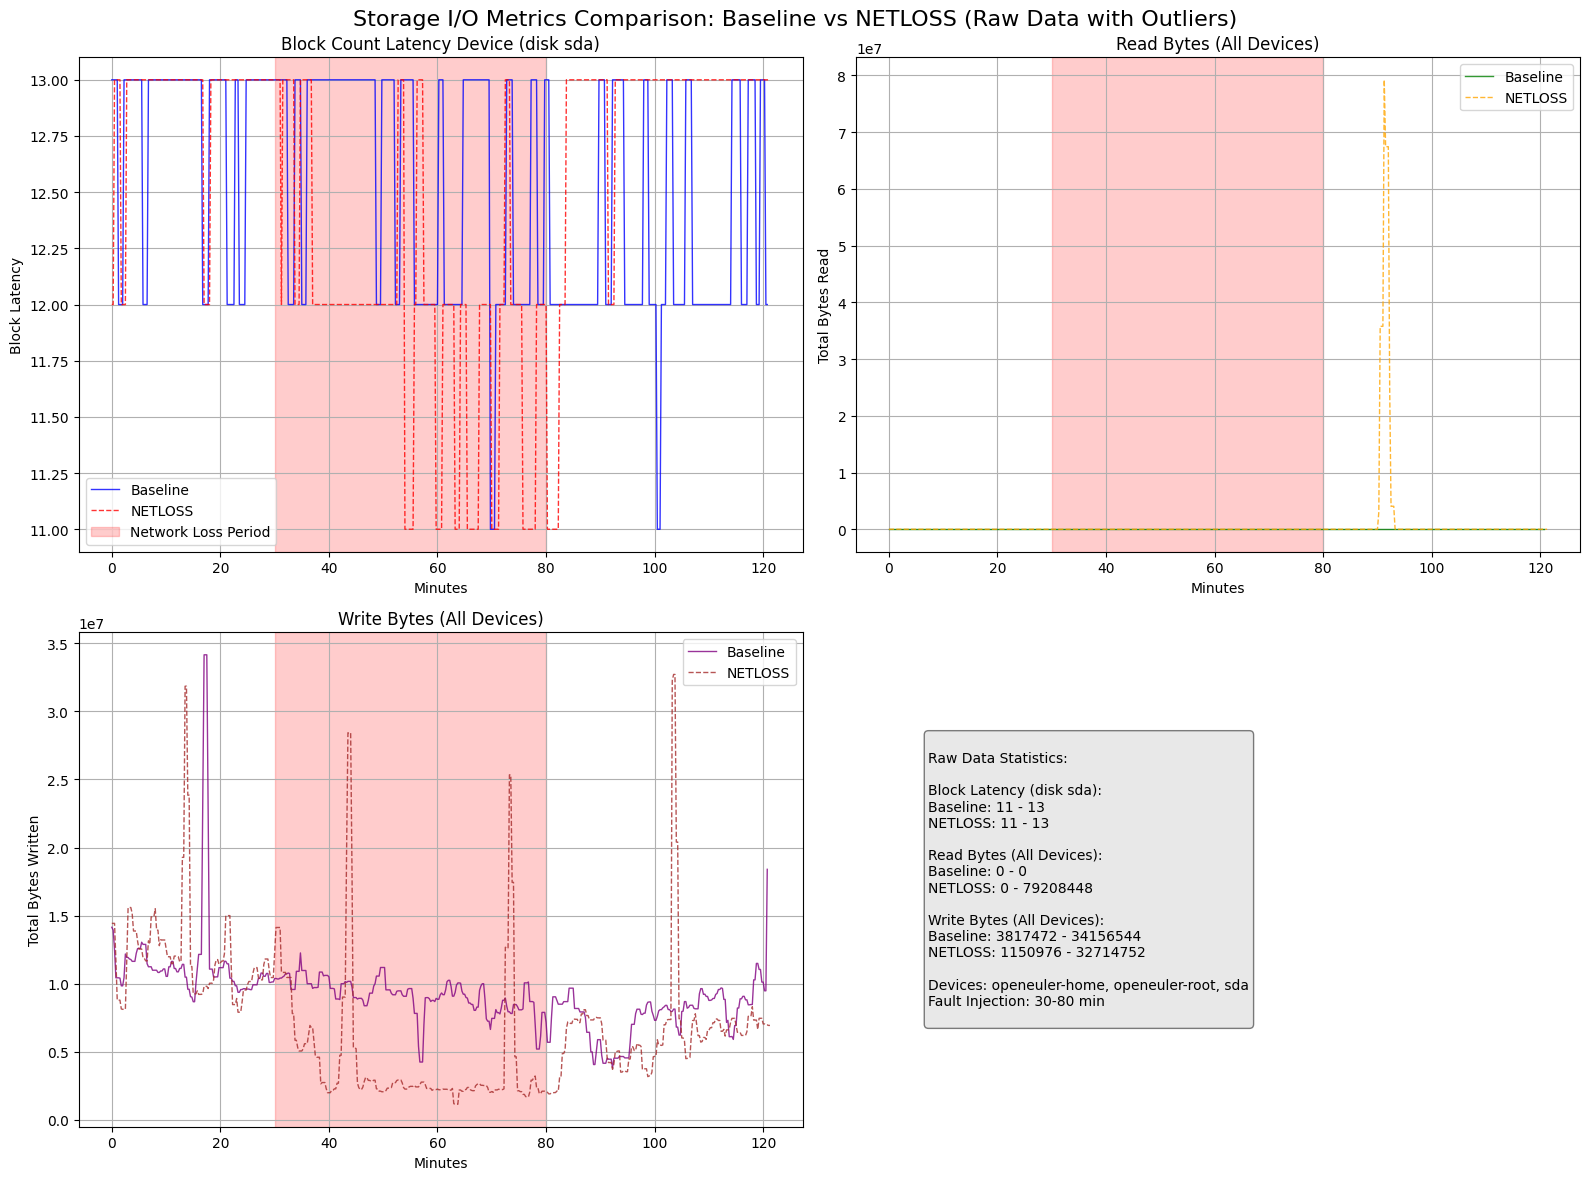

=== PULIZIA OUTLIERS PER TUTTE LE STORAGE FEATURES ===

1. BLOCK COUNT LATENCY DEVICE (disk sda):
   Baseline: 0 outliers rimossi
   NETLOSS: 0 outliers rimossi

2. READ BYTES (All Devices):
   Baseline: 0 outliers rimossi
   NETLOSS: 20 outliers rimossi

3. WRITE BYTES (All Devices):
   Baseline: 46 outliers rimossi
   NETLOSS: 49 outliers rimossi

=== INTERPOLAZIONE VALORI MANCANTI ===
Baseline Block Latency: 0 NaN values interpolated
NETLOSS Block Latency: 0 NaN values interpolated
Baseline Read Bytes: 0 NaN values interpolated
NETLOSS Read Bytes: 20 NaN values interpolated
Baseline Write Bytes: 46 NaN values interpolated
NETLOSS Write Bytes: 49 NaN values interpolated

=== PULIZIA COMPLETATA ===
Tutti i dataframe di storage puliti sono pronti per l'analisi!

=== RIEPILOGO OUTLIERS RIMOSSI ===
                     Feature  Baseline_Outliers  NETLOSS_Outliers
0   Block Latency (disk sda)                  0                 0
1   Read Bytes (All Devices)                  0             

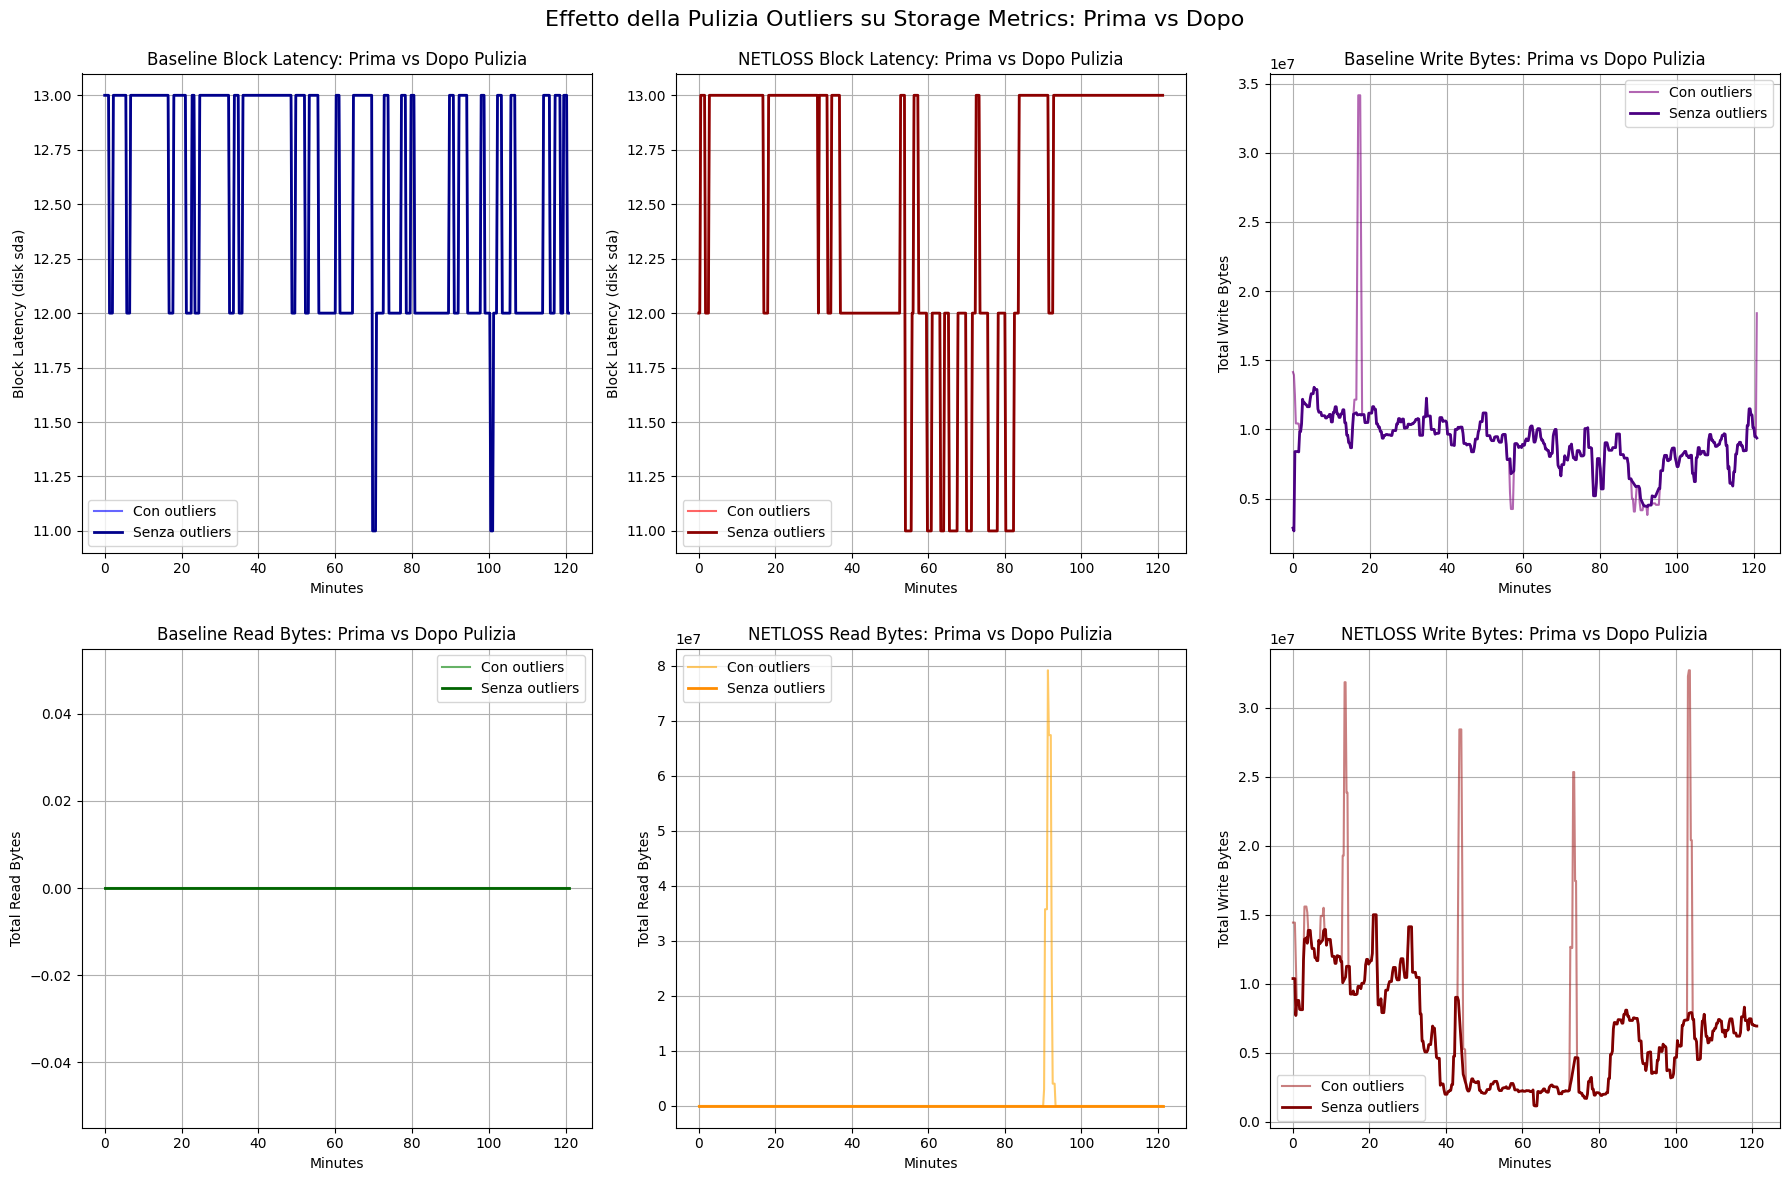

=== STATISTICHE PRIMA/DOPO PULIZIA OUTLIERS ===

BASELINE Block Latency:
  PRIMA - Media: 12.53, Std: 0.53
  DOPO  - Media: 12.53, Std: 0.53
  Riduzione std dev: 0.0%

NETLOSS Block Latency:
  PRIMA - Media: 12.50, Std: 0.68
  DOPO  - Media: 12.50, Std: 0.68
  Riduzione std dev: 0.0%

BASELINE Read Bytes:
  PRIMA - Media: 0.00, Std: 0.00
  DOPO  - Media: 0.00, Std: 0.00
  Riduzione std dev: nan%

NETLOSS Read Bytes:
  PRIMA - Media: 882578.44, Std: 7041920.75
  DOPO  - Media: 0.00, Std: 0.00
  Riduzione std dev: 100.0%

BASELINE Write Bytes:
  PRIMA - Media: 9290726.61, Std: 2879752.29
  DOPO  - Media: 9057529.65, Std: 1752055.52
  Riduzione std dev: 39.2%

NETLOSS Write Bytes:
  PRIMA - Media: 7112628.15, Std: 5371750.46
  DOPO  - Media: 6265721.15, Std: 3654437.41
  Riduzione std dev: 32.0%

=== ANALISI STATISTICA PER FASI - STORAGE METRICS (DATI PULITI) ===

--- BLOCK COUNT LATENCY (disk sda) ---
BASELINE:
          mean    std   min   max
phase                            
after   1

/tmp/ipykernel_609951/3564320408.py:356: RuntimeWarning: invalid value encountered in scalar divide
  std_reduction = ((df_orig['Total'].std() - df_clean['Total'].std()) / df_orig['Total'].std()) * 100


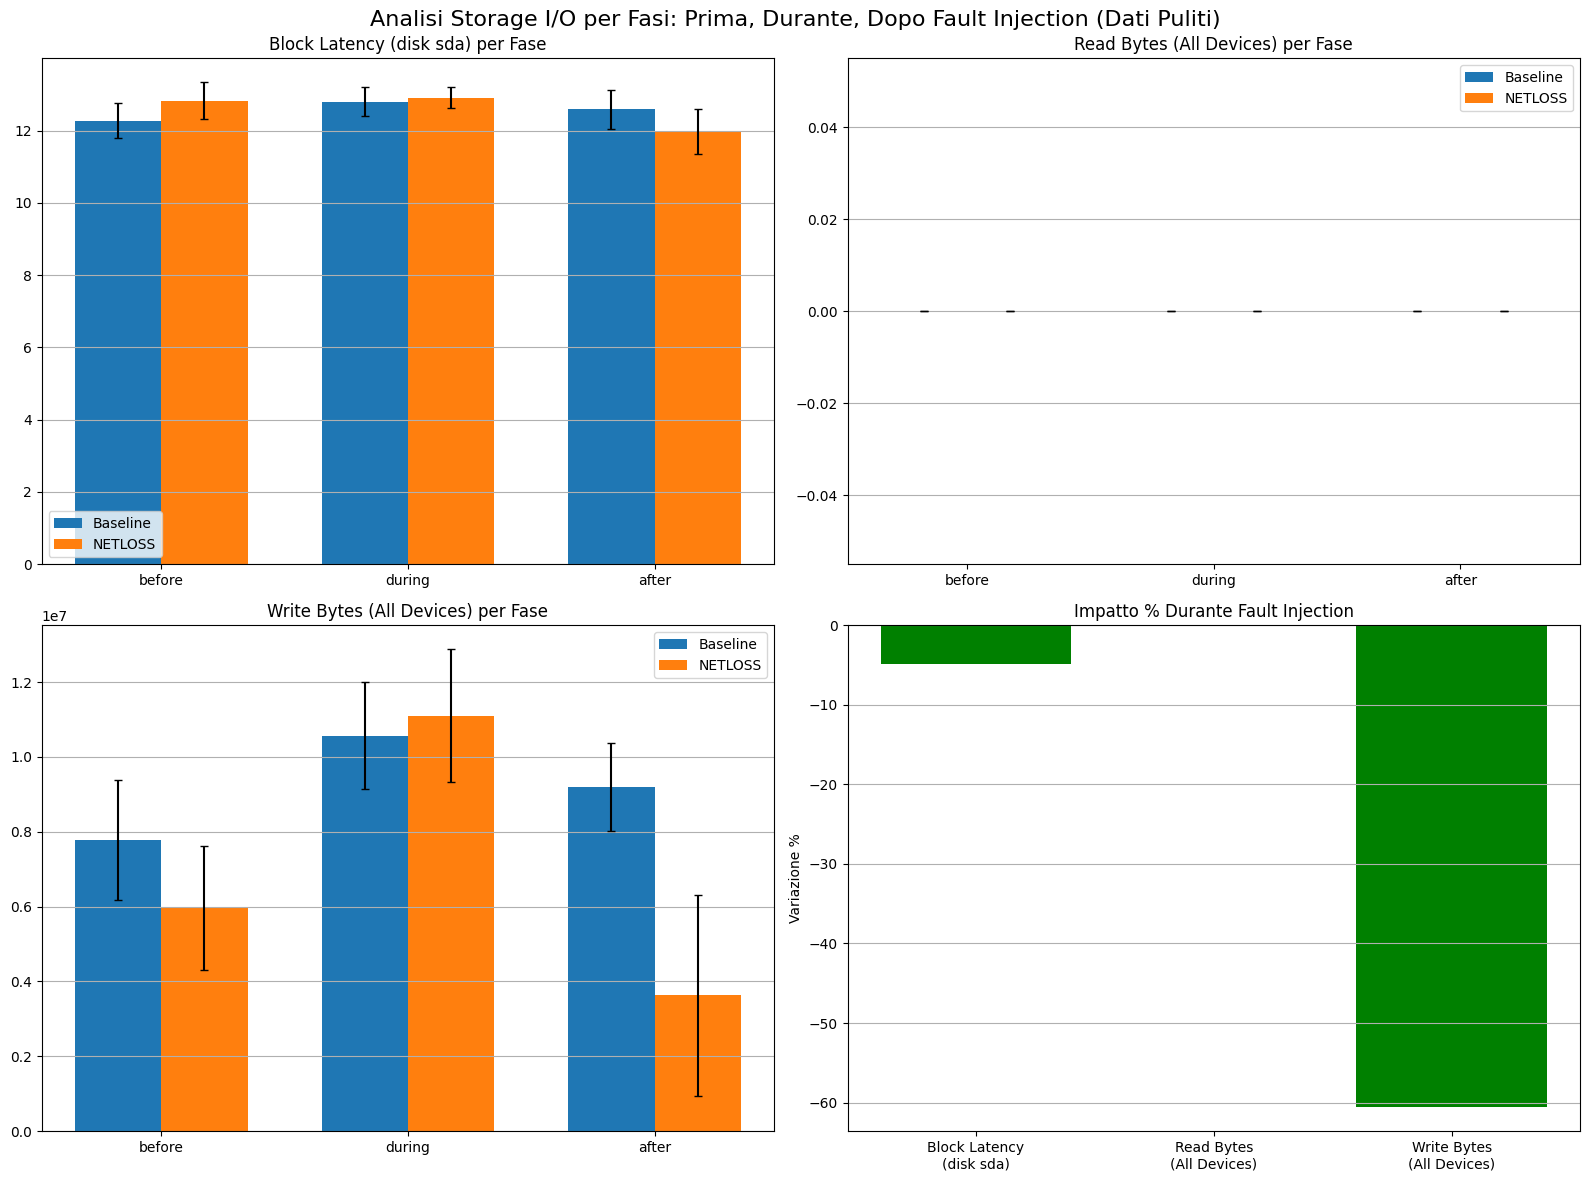

In [15]:
# ========== CELLA 1: DATA PREPARATION - STORAGE METRICS ==========

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# ---------- DATA LOADING ----------

df_block_count_latency_device = pd.read_csv("block_count_latency_device.csv")
df_read_bytes = pd.read_csv("read_bytes.csv")
df_write_bytes = pd.read_csv("write_bytes.csv")

df_baseline_block_count_latency_device = pd.read_csv("../../baseline/IO related/block_count_latency_device.csv")
df_baseline_read_bytes = pd.read_csv("../../baseline/IO related/read_bytes.csv")
df_baseline_write_bytes = pd.read_csv("../../baseline/IO related/write_bytes.csv")

# Add source column
df_block_count_latency_device["source"] = "NETLOSS"
df_read_bytes["source"] = "NETLOSS"
df_write_bytes["source"] = "NETLOSS"

df_baseline_block_count_latency_device["source"] = "BASELINE"
df_baseline_read_bytes["source"] = "BASELINE"
df_baseline_write_bytes["source"] = "BASELINE"

# Convert time columns to datetime
all_storage_dfs = [
    df_block_count_latency_device, df_read_bytes, df_write_bytes,
    df_baseline_block_count_latency_device, df_baseline_read_bytes, df_baseline_write_bytes
]

for df in all_storage_dfs:
    df["Time"] = pd.to_datetime(df["Time"])

# Synchronize test datasets with baseline timeline
time_offset = df_baseline_block_count_latency_device["Time"].min() - df_block_count_latency_device["Time"].min()
df_block_count_latency_device["Time"] += time_offset
df_read_bytes["Time"] += time_offset
df_write_bytes["Time"] += time_offset

# Convert timeline to minutes for better readability
for df in all_storage_dfs:
    df["Minutes"] = (df["Time"] - df["Time"].min()).dt.total_seconds() / 60

# Network failure parameters
delay_minutes = 30
duration_minutes = 50

# Identify storage device columns for different metrics
# Block latency has only 'disk sda' column
block_latency_cols = ['disk sda']

# Read/Write bytes have multiple device columns (excluding Time, Minutes, source)
read_write_device_cols = [col for col in df_read_bytes.columns 
                         if col not in ['Time', 'Minutes', 'source']]

print("Data preparation completed!")
print(f"Block latency columns: {block_latency_cols}")
print(f"Read/Write device columns: {read_write_device_cols}")
print(f"Time range: {df_baseline_read_bytes['Minutes'].min():.1f} - {df_baseline_read_bytes['Minutes'].max():.1f} minutes")
print(f"Fault injection period: {delay_minutes} - {delay_minutes + duration_minutes} minutes")

# ========== CELLA 2: VISUALIZZAZIONE DATI NATURALI (CON OUTLIERS) ==========

# Calculate totals for all storage metrics
# Block latency - single column, so Total = disk sda value
df_block_count_latency_device['Total'] = df_block_count_latency_device['disk sda']
df_baseline_block_count_latency_device['Total'] = df_baseline_block_count_latency_device['disk sda']

# Read/Write bytes - sum of all device columns
df_read_bytes['Total'] = df_read_bytes[read_write_device_cols].sum(axis=1)
df_baseline_read_bytes['Total'] = df_baseline_read_bytes[read_write_device_cols].sum(axis=1)

df_write_bytes['Total'] = df_write_bytes[read_write_device_cols].sum(axis=1)
df_baseline_write_bytes['Total'] = df_baseline_write_bytes[read_write_device_cols].sum(axis=1)

# Create dashboard with natural data (with outliers)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Storage I/O Metrics Comparison: Baseline vs NETLOSS (Raw Data with Outliers)', fontsize=16)

# Block Count Latency
axes[0,0].plot(df_baseline_block_count_latency_device['Minutes'], df_baseline_block_count_latency_device['Total'], 
               label='Baseline', linewidth=1, alpha=0.8, color='blue')
axes[0,0].plot(df_block_count_latency_device['Minutes'], df_block_count_latency_device['Total'], 
               label='NETLOSS', linewidth=1, linestyle='--', alpha=0.8, color='red')
axes[0,0].axvspan(delay_minutes, delay_minutes + duration_minutes, 
                  color='red', alpha=0.2, label="Network Loss Period")
axes[0,0].set_title("Block Count Latency Device (disk sda)")
axes[0,0].set_xlabel("Minutes")
axes[0,0].set_ylabel("Block Latency")
axes[0,0].grid(True)
axes[0,0].legend()

# Read Bytes
axes[0,1].plot(df_baseline_read_bytes['Minutes'], df_baseline_read_bytes['Total'], 
               label='Baseline', linewidth=1, alpha=0.8, color='green')
axes[0,1].plot(df_read_bytes['Minutes'], df_read_bytes['Total'], 
               label='NETLOSS', linewidth=1, linestyle='--', alpha=0.8, color='orange')
axes[0,1].axvspan(delay_minutes, delay_minutes + duration_minutes, 
                  color='red', alpha=0.2)
axes[0,1].set_title("Read Bytes (All Devices)")
axes[0,1].set_xlabel("Minutes")
axes[0,1].set_ylabel("Total Bytes Read")
axes[0,1].grid(True)
axes[0,1].legend()

# Write Bytes
axes[1,0].plot(df_baseline_write_bytes['Minutes'], df_baseline_write_bytes['Total'], 
               label='Baseline', linewidth=1, alpha=0.8, color='purple')
axes[1,0].plot(df_write_bytes['Minutes'], df_write_bytes['Total'], 
               label='NETLOSS', linewidth=1, linestyle='--', alpha=0.8, color='brown')
axes[1,0].axvspan(delay_minutes, delay_minutes + duration_minutes, 
                  color='red', alpha=0.2)
axes[1,0].set_title("Write Bytes (All Devices)")
axes[1,0].set_xlabel("Minutes")
axes[1,0].set_ylabel("Total Bytes Written")
axes[1,0].grid(True)
axes[1,0].legend()

# Summary statistics plot
axes[1,1].axis('off')
stats_text = f"""
Raw Data Statistics:

Block Latency (disk sda):
Baseline: {df_baseline_block_count_latency_device['Total'].min():.0f} - {df_baseline_block_count_latency_device['Total'].max():.0f}
NETLOSS: {df_block_count_latency_device['Total'].min():.0f} - {df_block_count_latency_device['Total'].max():.0f}

Read Bytes (All Devices):
Baseline: {df_baseline_read_bytes['Total'].min():.0f} - {df_baseline_read_bytes['Total'].max():.0f}
NETLOSS: {df_read_bytes['Total'].min():.0f} - {df_read_bytes['Total'].max():.0f}

Write Bytes (All Devices):
Baseline: {df_baseline_write_bytes['Total'].min():.0f} - {df_baseline_write_bytes['Total'].max():.0f}
NETLOSS: {df_write_bytes['Total'].min():.0f} - {df_write_bytes['Total'].max():.0f}

Devices: {', '.join(read_write_device_cols)}
Fault Injection: {delay_minutes}-{delay_minutes + duration_minutes} min
"""
axes[1,1].text(0.1, 0.5, stats_text, fontsize=10, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))

plt.tight_layout()
plt.show()

# ========== CELLA 3: PULIZIA OUTLIERS PER TUTTE LE STORAGE FEATURES ==========

def remove_outliers(df, columns, method='iqr', threshold=1.5):
    """
    Removes outliers from data using IQR or Z-score method
    """
    df_clean = df.copy()
    outliers_summary = {}
    
    if method == 'iqr':
        for col in columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - threshold * IQR
            upper_bound = Q3 + threshold * IQR
            
            # Create mask to identify outliers
            outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
            
            # Replace outliers with NaN
            df_clean.loc[outlier_mask, col] = np.nan
            
            # Store outlier info
            n_outliers = outlier_mask.sum()
            outliers_summary[col] = n_outliers
            
    elif method == 'zscore':
        for col in columns:
            z_scores = np.abs(stats.zscore(df[col].dropna()))
            outlier_mask = pd.Series(False, index=df.index)
            outlier_mask.loc[df[col].dropna().index] = z_scores > threshold
            
            # Replace outliers with NaN
            df_clean.loc[outlier_mask, col] = np.nan
            
            # Store outlier info
            n_outliers = outlier_mask.sum()
            outliers_summary[col] = n_outliers
    
    return df_clean, outliers_summary

# Apply outlier cleaning to all storage features
print("=== PULIZIA OUTLIERS PER TUTTE LE STORAGE FEATURES ===\n")

# Clean Block Count Latency (single column: 'disk sda')
print("1. BLOCK COUNT LATENCY DEVICE (disk sda):")
df_baseline_block_latency_clean, outliers_base_block = remove_outliers(
    df_baseline_block_count_latency_device, block_latency_cols, method='iqr', threshold=2.0)
df_block_latency_clean, outliers_test_block = remove_outliers(
    df_block_count_latency_device, block_latency_cols, method='iqr', threshold=2.0)
print(f"   Baseline: {sum(outliers_base_block.values())} outliers rimossi")
print(f"   NETLOSS: {sum(outliers_test_block.values())} outliers rimossi")

# Clean Read Bytes (multiple device columns)
print("\n2. READ BYTES (All Devices):")
df_baseline_read_clean, outliers_base_read = remove_outliers(
    df_baseline_read_bytes, read_write_device_cols, method='iqr', threshold=2.0)
df_read_clean, outliers_test_read = remove_outliers(
    df_read_bytes, read_write_device_cols, method='iqr', threshold=2.0)
print(f"   Baseline: {sum(outliers_base_read.values())} outliers rimossi")
print(f"   NETLOSS: {sum(outliers_test_read.values())} outliers rimossi")

# Clean Write Bytes (multiple device columns)
print("\n3. WRITE BYTES (All Devices):")
df_baseline_write_clean, outliers_base_write = remove_outliers(
    df_baseline_write_bytes, read_write_device_cols, method='iqr', threshold=2.0)
df_write_clean, outliers_test_write = remove_outliers(
    df_write_bytes, read_write_device_cols, method='iqr', threshold=2.0)
print(f"   Baseline: {sum(outliers_base_write.values())} outliers rimossi")
print(f"   NETLOSS: {sum(outliers_test_write.values())} outliers rimossi")

# Interpolate NaN values to maintain data continuity
print("\n=== INTERPOLAZIONE VALORI MANCANTI ===")

# For block latency (single column)
for df, name in [(df_baseline_block_latency_clean, "Baseline Block Latency"),
                 (df_block_latency_clean, "NETLOSS Block Latency")]:
    nan_before = df[block_latency_cols].isna().sum().sum()
    for col in block_latency_cols:
        df[col] = df[col].interpolate(method='linear')
    print(f"{name}: {nan_before} NaN values interpolated")

# For read/write bytes (multiple columns)
for df, name in [(df_baseline_read_clean, "Baseline Read Bytes"),
                 (df_read_clean, "NETLOSS Read Bytes"),
                 (df_baseline_write_clean, "Baseline Write Bytes"),
                 (df_write_clean, "NETLOSS Write Bytes")]:
    nan_before = df[read_write_device_cols].isna().sum().sum()
    for col in read_write_device_cols:
        df[col] = df[col].interpolate(method='linear')
    print(f"{name}: {nan_before} NaN values interpolated")

# Calculate new totals for cleaned data
# Block latency - single column
df_baseline_block_latency_clean['Total'] = df_baseline_block_latency_clean['disk sda']
df_block_latency_clean['Total'] = df_block_latency_clean['disk sda']

# Read/Write bytes - sum of all device columns
df_baseline_read_clean['Total'] = df_baseline_read_clean[read_write_device_cols].sum(axis=1)
df_read_clean['Total'] = df_read_clean[read_write_device_cols].sum(axis=1)
df_baseline_write_clean['Total'] = df_baseline_write_clean[read_write_device_cols].sum(axis=1)
df_write_clean['Total'] = df_write_clean[read_write_device_cols].sum(axis=1)

print("\n=== PULIZIA COMPLETATA ===")
print("Tutti i dataframe di storage puliti sono pronti per l'analisi!")

# Summary of outliers removed
outlier_summary = pd.DataFrame({
    'Feature': ['Block Latency (disk sda)', 'Read Bytes (All Devices)', 'Write Bytes (All Devices)'],
    'Baseline_Outliers': [
        sum(outliers_base_block.values()),
        sum(outliers_base_read.values()),
        sum(outliers_base_write.values())
    ],
    'NETLOSS_Outliers': [
        sum(outliers_test_block.values()),
        sum(outliers_test_read.values()),
        sum(outliers_test_write.values())
    ]
})

print("\n=== RIEPILOGO OUTLIERS RIMOSSI ===")
print(outlier_summary)

# ========== CELLA 4: CONFRONTO PRIMA/DOPO PULIZIA OUTLIERS ==========

# Create comparison dashboard showing before/after outlier cleaning
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Effetto della Pulizia Outliers su Storage Metrics: Prima vs Dopo', fontsize=16)

# 1. Block Latency Comparison
axes[0,0].plot(df_baseline_block_count_latency_device['Minutes'], 
               df_baseline_block_count_latency_device['Total'], 
               label='Con outliers', alpha=0.6, color='blue')
axes[0,0].plot(df_baseline_block_latency_clean['Minutes'], 
               df_baseline_block_latency_clean['Total'], 
               label='Senza outliers', linewidth=2, color='darkblue')
axes[0,0].set_title('Baseline Block Latency: Prima vs Dopo Pulizia')
axes[0,0].set_xlabel('Minutes')
axes[0,0].set_ylabel('Block Latency (disk sda)')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(df_block_count_latency_device['Minutes'], 
               df_block_count_latency_device['Total'], 
               label='Con outliers', alpha=0.6, color='red')
axes[0,1].plot(df_block_latency_clean['Minutes'], 
               df_block_latency_clean['Total'], 
               label='Senza outliers', linewidth=2, color='darkred')
axes[0,1].set_title('NETLOSS Block Latency: Prima vs Dopo Pulizia')
axes[0,1].set_xlabel('Minutes')
axes[0,1].set_ylabel('Block Latency (disk sda)')
axes[0,1].legend()
axes[0,1].grid(True)

# 2. Read Bytes Comparison
axes[1,0].plot(df_baseline_read_bytes['Minutes'], df_baseline_read_bytes['Total'], 
               label='Con outliers', alpha=0.6, color='green')
axes[1,0].plot(df_baseline_read_clean['Minutes'], df_baseline_read_clean['Total'], 
               label='Senza outliers', linewidth=2, color='darkgreen')
axes[1,0].set_title('Baseline Read Bytes: Prima vs Dopo Pulizia')
axes[1,0].set_xlabel('Minutes')
axes[1,0].set_ylabel('Total Read Bytes')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(df_read_bytes['Minutes'], df_read_bytes['Total'], 
               label='Con outliers', alpha=0.6, color='orange')
axes[1,1].plot(df_read_clean['Minutes'], df_read_clean['Total'], 
               label='Senza outliers', linewidth=2, color='darkorange')
axes[1,1].set_title('NETLOSS Read Bytes: Prima vs Dopo Pulizia')
axes[1,1].set_xlabel('Minutes')
axes[1,1].set_ylabel('Total Read Bytes')
axes[1,1].legend()
axes[1,1].grid(True)

# 3. Write Bytes Comparison
axes[0,2].plot(df_baseline_write_bytes['Minutes'], df_baseline_write_bytes['Total'], 
               label='Con outliers', alpha=0.6, color='purple')
axes[0,2].plot(df_baseline_write_clean['Minutes'], df_baseline_write_clean['Total'], 
               label='Senza outliers', linewidth=2, color='indigo')
axes[0,2].set_title('Baseline Write Bytes: Prima vs Dopo Pulizia')
axes[0,2].set_xlabel('Minutes')
axes[0,2].set_ylabel('Total Write Bytes')
axes[0,2].legend()
axes[0,2].grid(True)

axes[1,2].plot(df_write_bytes['Minutes'], df_write_bytes['Total'], 
               label='Con outliers', alpha=0.6, color='brown')
axes[1,2].plot(df_write_clean['Minutes'], df_write_clean['Total'], 
               label='Senza outliers', linewidth=2, color='maroon')
axes[1,2].set_title('NETLOSS Write Bytes: Prima vs Dopo Pulizia')
axes[1,2].set_xlabel('Minutes')
axes[1,2].set_ylabel('Total Write Bytes')
axes[1,2].legend()
axes[1,2].grid(True)

plt.tight_layout()
plt.show()

# Statistical comparison before/after cleaning
print("=== STATISTICHE PRIMA/DOPO PULIZIA OUTLIERS ===\n")

def compare_storage_stats(df_orig, df_clean, feature_name):
    print(f"{feature_name}:")
    print(f"  PRIMA - Media: {df_orig['Total'].mean():.2f}, Std: {df_orig['Total'].std():.2f}")
    print(f"  DOPO  - Media: {df_clean['Total'].mean():.2f}, Std: {df_clean['Total'].std():.2f}")
    std_reduction = ((df_orig['Total'].std() - df_clean['Total'].std()) / df_orig['Total'].std()) * 100
    print(f"  Riduzione std dev: {std_reduction:.1f}%\n")

# Compare all storage features
compare_storage_stats(df_baseline_block_count_latency_device, df_baseline_block_latency_clean, "BASELINE Block Latency")
compare_storage_stats(df_block_count_latency_device, df_block_latency_clean, "NETLOSS Block Latency")
compare_storage_stats(df_baseline_read_bytes, df_baseline_read_clean, "BASELINE Read Bytes")
compare_storage_stats(df_read_bytes, df_read_clean, "NETLOSS Read Bytes")
compare_storage_stats(df_baseline_write_bytes, df_baseline_write_clean, "BASELINE Write Bytes")
compare_storage_stats(df_write_bytes, df_write_clean, "NETLOSS Write Bytes")

# ========== CELLA 5: ANALISI FASI (PRIMA/DURANTE/DOPO) - DATI PULITI ==========

# Function to add phase column
def add_phase_column(df):
    df['phase'] = 'before'  
    df.loc[(df['Minutes'] >= delay_minutes) & (df['Minutes'] <= delay_minutes + duration_minutes), 'phase'] = 'during'  
    df.loc[df['Minutes'] > delay_minutes + duration_minutes, 'phase'] = 'after' 
    return df

# Add phase information to all cleaned dataframes
all_clean_storage_dfs_with_phases = [
    (df_baseline_block_latency_clean, "Baseline Block Latency"),
    (df_block_latency_clean, "NETLOSS Block Latency"),
    (df_baseline_read_clean, "Baseline Read Bytes"),
    (df_read_clean, "NETLOSS Read Bytes"),
    (df_baseline_write_clean, "Baseline Write Bytes"),
    (df_write_clean, "NETLOSS Write Bytes")
]

for df, name in all_clean_storage_dfs_with_phases:
    add_phase_column(df)

print("=== ANALISI STATISTICA PER FASI - STORAGE METRICS (DATI PULITI) ===\n")

# Function to analyze phases for each storage feature
def analyze_storage_phases(df_baseline, df_netloss, feature_name):
    print(f"--- {feature_name} ---")
    
    # Calculate statistics by phase
    stats_baseline = df_baseline.groupby('phase')['Total'].agg(['mean', 'std', 'min', 'max'])
    stats_netloss = df_netloss.groupby('phase')['Total'].agg(['mean', 'std', 'min', 'max'])
    
    print("BASELINE:")
    print(stats_baseline.round(3))
    print("\nNETLOSS:")
    print(stats_netloss.round(3))
    
    # T-test for statistical significance
    t_tests = {}
    for phase in ['before', 'during', 'after']:
        baseline_data = df_baseline[df_baseline['phase'] == phase]['Total'].dropna()
        netloss_data = df_netloss[df_netloss['phase'] == phase]['Total'].dropna()
        
        if len(baseline_data) > 1 and len(netloss_data) > 1:
            t_stat, p_value = stats.ttest_ind(baseline_data, netloss_data)
            t_tests[phase] = {'t': t_stat, 'p': p_value}
    
    print("\nTEST STATISTICI:")
    for phase, test in t_tests.items():
        sig = "Significativo" if test['p'] < 0.05 else "Non significativo"
        print(f"{phase}: t={test['t']:.3f}, p={test['p']:.4f} ({sig})")
    
    # Calculate percentage impact
    impact = {}
    for phase in ['before', 'during', 'after']:
        baseline_mean = stats_baseline.loc[phase, 'mean']
        netloss_mean = stats_netloss.loc[phase, 'mean']
        if baseline_mean != 0:
            impact[phase] = ((netloss_mean - baseline_mean) / baseline_mean) * 100
        else:
            impact[phase] = float('inf')
    
    print("\nIMPATTO PERCENTUALE:")
    for phase, change in impact.items():
        print(f"{phase}: {change:.2f}%")
    
    print("\n" + "="*50 + "\n")
    
    return stats_baseline, stats_netloss, t_tests, impact

# Analyze all storage features
storage_results = {}

# 1. Block Latency Analysis
storage_results['block_latency'] = analyze_storage_phases(
    df_baseline_block_latency_clean, df_block_latency_clean, "BLOCK COUNT LATENCY (disk sda)")

# 2. Read Bytes Analysis  
storage_results['read_bytes'] = analyze_storage_phases(
    df_baseline_read_clean, df_read_clean, "READ BYTES (All Devices)")

# 3. Write Bytes Analysis
storage_results['write_bytes'] = analyze_storage_phases(
    df_baseline_write_clean, df_write_clean, "WRITE BYTES (All Devices)")

# Create summary visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Analisi Storage I/O per Fasi: Prima, Durante, Dopo Fault Injection (Dati Puliti)', fontsize=16)

# Block Latency phase analysis
phases = ['before', 'during', 'after']
x = np.arange(len(phases))
width = 0.35

stats_base_block, stats_test_block, _, _ = storage_results['block_latency']
axes[0,0].bar(x - width/2, stats_base_block['mean'], width, label='Baseline', 
              yerr=stats_base_block['std'], capsize=3)
axes[0,0].bar(x + width/2, stats_test_block['mean'], width, label='NETLOSS', 
              yerr=stats_test_block['std'], capsize=3)
axes[0,0].set_title('Block Latency (disk sda) per Fase')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(phases)
axes[0,0].legend()
axes[0,0].grid(axis='y')

# Read Bytes phase analysis
stats_base_read, stats_test_read, _, _ = storage_results['read_bytes']
axes[0,1].bar(x - width/2, stats_base_read['mean'], width, label='Baseline', 
              yerr=stats_base_read['std'], capsize=3)
axes[0,1].bar(x + width/2, stats_test_read['mean'], width, label='NETLOSS', 
              yerr=stats_test_read['std'], capsize=3)
axes[0,1].set_title('Read Bytes (All Devices) per Fase')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(phases)
axes[0,1].legend()
axes[0,1].grid(axis='y')

# Write Bytes phase analysis
stats_base_write, stats_test_write, _, _ = storage_results['write_bytes']
axes[1,0].bar(x - width/2, stats_base_write['mean'], width, label='Baseline', 
              yerr=stats_base_write['std'], capsize=3)
axes[1,0].bar(x + width/2, stats_test_write['mean'], width, label='NETLOSS', 
              yerr=stats_test_write['std'], capsize=3)
axes[1,0].set_title('Write Bytes (All Devices) per Fase')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(phases)
axes[1,0].legend()
axes[1,0].grid(axis='y')

# Summary impact plot
feature_names = ['Block Latency\n(disk sda)', 'Read Bytes\n(All Devices)', 'Write Bytes\n(All Devices)']
impact_during = [
    storage_results['block_latency'][3]['during'],
    storage_results['read_bytes'][3]['during'],
    storage_results['write_bytes'][3]['during']
]

axes[1,1].bar(feature_names, impact_during, 
              color=['red' if x > 0 else 'green' for x in impact_during])
axes[1,1].set_title('Impatto % Durante Fault Injection')
axes[1,1].set_ylabel('Variazione %')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].grid(axis='y')
axes[1,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Create comprehensive summary table
storage_summary_data = []
for feature, (stats_base, stats_test, t_tests, impact) in storage_results.items():
    for phase in ['before', 'during', 'after']:
        storage_summary_data.append({
            'Feature': feature.upper().replace('_', ' '),
            'Phase': phase,
            'Baseline_Mean': stats_base.loc[phase, 'mean'],
            'NETLOSS_Mean': stats_test.loc[phase, 'mean'],
            'Impact_%': impact[phase],
            'P_Value': t_tests.get(phase, {}).get('p', 'N/A'),
            'Significant': 'Yes' if isinstance(t_tests.get(phase, {}).get('p', 1), float) and t_tests.get(phase, {}).get('p', 1) < 0.05 else 'No'
        })

storage_summary_df = pd.DataFrame(storage_summary_data)

## block count latency device

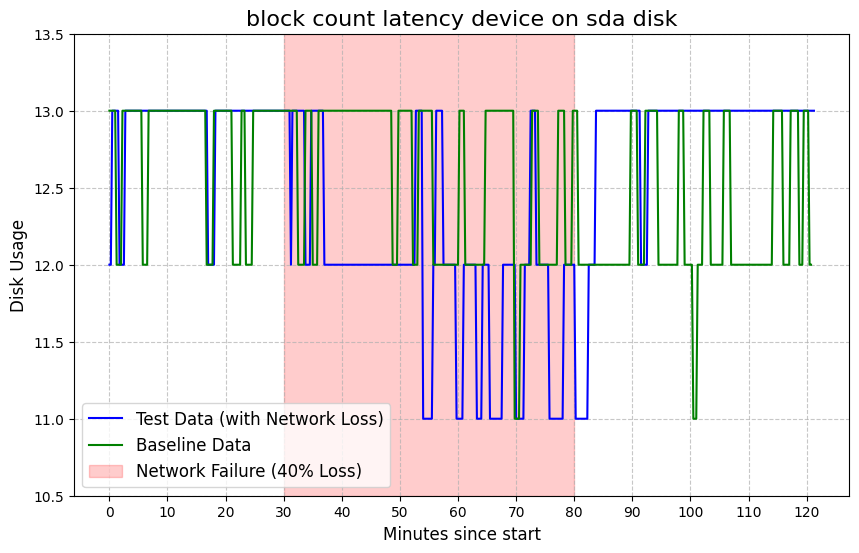

In [ ]:
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(df_block_count_latency_device["Minutes"], df_block_count_latency_device["disk sda"], 
         label="Test Data (with Network Loss)", color='blue', linewidth=1.5)
plt.plot(df_baseline_block_count_latency_device["Minutes"], df_baseline_block_count_latency_device["disk sda"], 
         label="Baseline Data", color='green', linewidth=1.5)
plt.axvspan(delay, delay + duration, color='red', alpha=0.2, label="Network Failure (40% Loss)")
plt.title("block count latency device on sda disk", fontsize=16)
plt.xlabel("Minutes since start", fontsize=12)
plt.ylabel("Disk Usage", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(10.5, 13.5)
plt.legend(loc='best', fontsize=12)
plt.xticks(np.arange(0, max(df_block_count_latency_device["Minutes"].max(), 
                           df_baseline_block_count_latency_device["Minutes"].max())+1, 10))

plt.show()

## read bytes

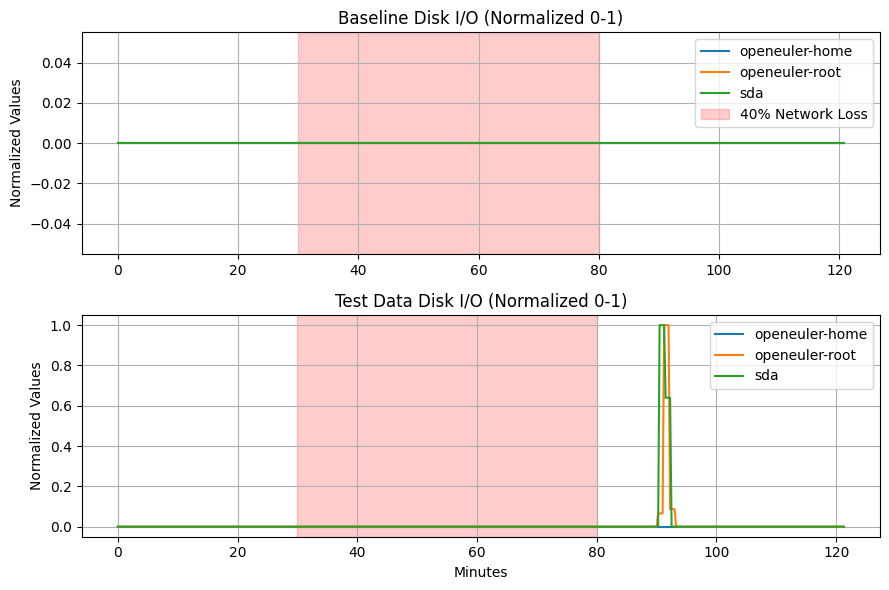

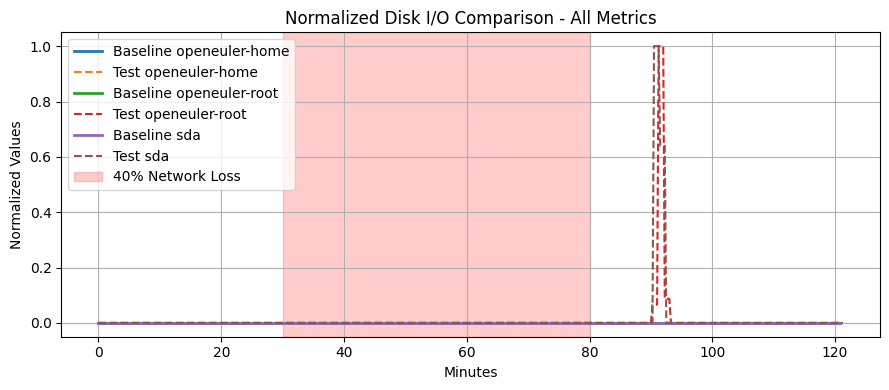

In [13]:
df_read_bytes["Minutes"] = (df_read_bytes["Time"] - df_read_bytes["Time"].min()).dt.total_seconds() / 60
df_baseline_read_bytes["Minutes"] = (df_baseline_read_bytes["Time"] - df_baseline_read_bytes["Time"].min()).dt.total_seconds() / 60

delay = 30  # 30 minutes (1800 seconds)
duration = 50  # 50 minutes (3000 seconds)

# Get columns to analyze
cols = ['openeuler-home', 'openeuler-root', 'sda']

# Create normalization function
def normalize_df(df, columns):
    df_norm = df.copy()
    for col in columns:
        min_val = df[col].min()
        max_val = df[col].max()
        if max_val > min_val:
            df_norm[col] = (df[col] - min_val) / (max_val - min_val)
        else:
            df_norm[col] = 0
    return df_norm

# Normalize the data
df_baseline_norm = normalize_df(df_baseline_read_bytes, cols)
df_read_norm = normalize_df(df_read_bytes, cols)

# Create figure for normalized line plots - one for each dataset
plt.figure(figsize=(9, 6))

# Top subplot for baseline
plt.subplot(2, 1, 1)
for col in cols:
    plt.plot(df_baseline_norm["Minutes"], df_baseline_norm[col], label=col)
plt.title("Baseline Disk I/O (Normalized 0-1)")
plt.ylabel("Normalized Values")
plt.axvspan(delay, delay + duration, color='red', alpha=0.2, label="40% Network Loss")
plt.grid(True)
plt.legend(loc='upper right')

# Bottom subplot for test
plt.subplot(2, 1, 2)
for col in cols:
    plt.plot(df_read_norm ["Minutes"], df_read_norm [col], label=col)
plt.title("Test Data Disk I/O (Normalized 0-1)")
plt.xlabel("Minutes")
plt.ylabel("Normalized Values")
plt.grid(True)
plt.legend(loc='upper right')
plt.axvspan(delay, delay + duration, color='red', alpha=0.2, label="40% Network Loss")
plt.tight_layout()

# Create a separate figure for all columns comparison
plt.figure(figsize=(9, 4))
for col in cols:
    plt.plot(df_baseline_norm["Minutes"], df_baseline_norm[col], label=f"Baseline {col}", linewidth=2)
    plt.plot(df_read_norm ["Minutes"], df_read_norm [col], label=f"Test {col}", linewidth=1.5, linestyle='--')
plt.title("Normalized Disk I/O Comparison - All Metrics")
plt.xlabel("Minutes")
plt.ylabel("Normalized Values")
plt.axvspan(delay, delay + duration, color='red', alpha=0.2, label="40% Network Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()

## write bytes

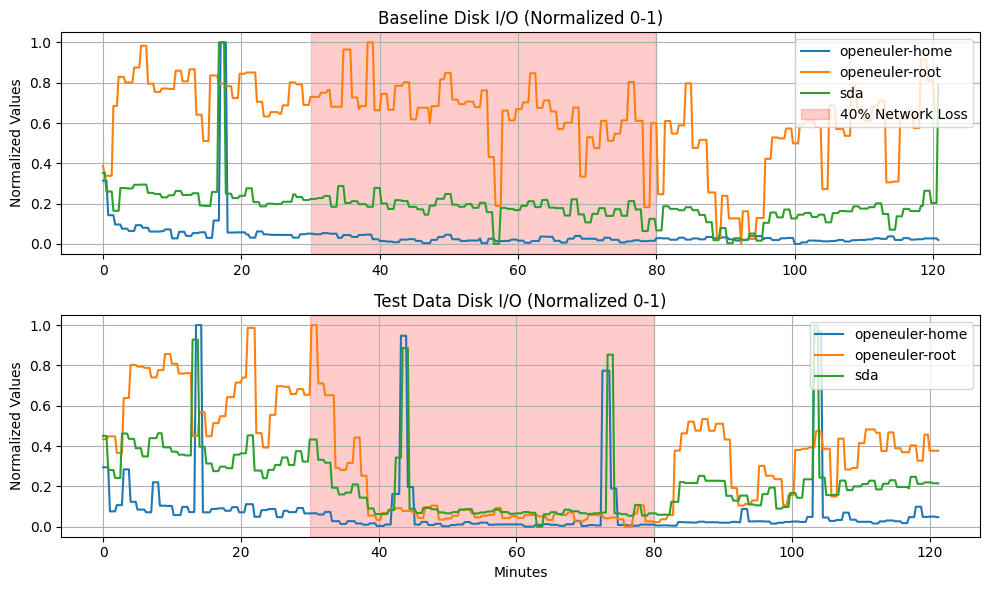

In [ ]:
# Calculate minutes since start for each dataset
df_write_bytes["Minutes"] = (df_write_bytes["Time"] - df_write_bytes["Time"].min()).dt.total_seconds() / 60
df_baseline_write_bytes["Minutes"] = (df_baseline_write_bytes["Time"] - df_baseline_write_bytes["Time"].min()).dt.total_seconds() / 60

# Define when the failure was injected (from the log file)
delay = 30  # 30 minutes (1800 seconds)
duration = 50  # 50 minutes (3000 seconds)

# Get columns to analyze
cols = ['openeuler-home', 'openeuler-root', 'sda']

# Create normalization function
def normalize_df(df, columns):
    df_norm = df.copy()
    for col in columns:
        min_val = df[col].min()
        max_val = df[col].max()
        if max_val > min_val:
            df_norm[col] = (df[col] - min_val) / (max_val - min_val)
        else:
            df_norm[col] = 0
    return df_norm

# Normalize the data
df_baseline_norm = normalize_df(df_baseline_write_bytes, cols)
df_write_bytes_norm= normalize_df(df_write_bytes, cols)

# Create figure for normalized line plots - one for each dataset
plt.figure(figsize=(10, 6))

# Top subplot for baseline
plt.subplot(2, 1, 1)
for col in cols:
    plt.plot(df_baseline_norm["Minutes"], df_baseline_norm[col], label=col)
plt.title("Baseline Disk I/O (Normalized 0-1)")
plt.ylabel("Normalized Values")
plt.axvspan(delay, delay + duration, color='red', alpha=0.2, label="40% Network Loss")
plt.grid(True)
plt.legend(loc='upper right')

# Bottom subplot for test
plt.subplot(2, 1, 2)
for col in cols:
    plt.plot(df_write_bytes_norm["Minutes"], df_write_bytes_norm[col], label=col)
plt.title("Test Data Disk I/O (Normalized 0-1)")
plt.xlabel("Minutes")
plt.ylabel("Normalized Values")
plt.grid(True)
plt.legend(loc='upper right')
plt.axvspan(delay, delay + duration, color='red', alpha=0.2, label="40% Network Loss")
plt.tight_layout()
plt.savefig('disk_io_comparison_normalized.png', dpi=300)